In [1]:
import pandas as pd

antiga = pd.read_csv(r'C:\Users\samuel.bandeira\lstm-forecast-demanda\data\raw\vendas_base_antiga.csv', sep=None, engine='python')
nova = pd.read_csv(r'C:\Users\samuel.bandeira\lstm-forecast-demanda\data\raw\vendas_base_nova.csv', sep=None, engine='python')

print("=== BASE ANTIGA ===")
print(antiga.shape)
print(antiga.columns.tolist())
print(antiga.head(3))

print("\n=== BASE NOVA ===")
print(nova.shape)
print(nova.columns.tolist())
print(nova.head(3))

=== BASE ANTIGA ===
(327007, 7)
['\ufeffDATA', 'DS_EMPRESA', 'Região', 'UF', 'DS_LINHA', 'Vendas_Vol_Ton', 'Vendas_Val_MM']
              ﻿DATA DS_EMPRESA Região  UF     DS_LINHA Vendas_Vol_Ton  \
0  12/01/2022 00:00        ACI    Sul  SC  Chapa Plana              5   
1  19/10/2021 00:00        ACI    Sul  SC  Chapa Plana              5   
2  13/05/2021 00:00        ACI    Sul  SC  Chapa Plana             25   

  Vendas_Val_MM  
0         45,32  
1          45,6  
2        249,11  

=== BASE NOVA ===
(18817, 7)
['\ufeffdata_criacao', 'descricao_empresa_2', 'descricao_linha', 'Região', 'UF', 'Vendas_Vol_Ton', 'Vendas_Val_MM']
      ﻿data_criacao descricao_empresa_2 descricao_linha    Região  UF  \
0  07/05/2026 00:00                 ACC            Tela  Nordeste  CE   
1  17/01/2026 00:00                 ACC            Tela  Nordeste  CE   
2  24/01/2026 00:00                 ACC            Tela  Nordeste  CE   

  Vendas_Vol_Ton Vendas_Val_MM  
0        5,28374      36,54608  
1     

In [4]:
antiga.columns = ['data', 'empresa', 'regiao', 'uf', 'linha', 'vol_ton', 'val_mm']
nova.columns = ['data', 'empresa', 'linha', 'regiao', 'uf', 'vol_ton', 'val_mm']

# Remove ponto de milhar, substitui vírgula decimal por ponto
for col in ['vol_ton', 'val_mm']:
    antiga[col] = antiga[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
    nova[col] = nova[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Converte data para datetime
antiga['data'] = pd.to_datetime(antiga['data'], dayfirst=True)
nova['data'] = pd.to_datetime(nova['data'], dayfirst=True)

# Unifica as duas bases
df = pd.concat([antiga, nova], ignore_index=True)

# Agrega para nível mensal
df['mes'] = df['data'].dt.to_period('M')

df_mensal = df.groupby(['mes', 'empresa', 'regiao', 'uf', 'linha'], as_index=False).agg(
    vol_ton=('vol_ton', 'sum'),
    val_mm=('val_mm', 'sum')
)

print(df_mensal.shape)
print(df_mensal.dtypes)
print(df_mensal.head(5))
print("\nPeríodo coberto:")
print(df_mensal['mes'].min(), "até", df_mensal['mes'].max())

(43406, 7)
mes        period[M]
empresa       object
regiao        object
uf            object
linha         object
vol_ton      float64
val_mm       float64
dtype: object
       mes empresa        regiao  uf           linha  vol_ton  val_mm
0  2019-01     ACC  Centro Oeste  DF      Inox Chapa     1.47   18.37
1  2019-01     ACC  Centro Oeste  GO  Barra Laminada     0.60    2.39
2  2019-01     ACC  Centro Oeste  GO     Inox Bobina     5.12   53.45
3  2019-01     ACC  Centro Oeste  MS  Barra Laminada     9.22   36.15
4  2019-01     ACC  Centro Oeste  MT  Barra Laminada    13.63   51.57

Período coberto:
2019-01 até 2026-05


In [5]:
print("=== LINHAS POR EMPRESA ===")
print(df_mensal['empresa'].value_counts())

print("\n=== LINHAS POR LINHA DE PRODUTO ===")
print(df_mensal['linha'].value_counts())

print("\n=== VOLUME TOTAL POR LINHA (top 10) ===")
print(df_mensal.groupby('linha')['vol_ton'].sum().sort_values(ascending=False).head(10))

=== LINHAS POR EMPRESA ===
empresa
ACI    22432
SIN    12577
ACC     8397
Name: count, dtype: int64

=== LINHAS POR LINHA DE PRODUTO ===
linha
CA-60             3616
Tela              3502
CA-50             3343
Trelica           3271
Inox Chapa        2718
Arame             2716
Tubo              2715
Chapa Plana       2695
Perfis            2365
Tela Coluna       2201
Lambril           2127
Bobininha         1757
Articulada        1743
Barra Laminada    1586
Telha             1466
Caixilho          1402
Inox Bobina       1385
Bobina             931
Bobina Slitter     869
FM                 424
Chapa A-36         274
Sucata             130
Inox Tubo           71
Tarugo              47
Inox Sucata         38
Inox Barra           8
Gusa                 3
Aluminio Tubo        2
Suporte              1
Name: count, dtype: int64

=== VOLUME TOTAL POR LINHA (top 10) ===
linha
CA-50          2.615668e+06
Tubo           1.283679e+06
Chapa Plana    4.136217e+05
Perfis         3.768269e+05
CA-60

Base salva em data/processed/


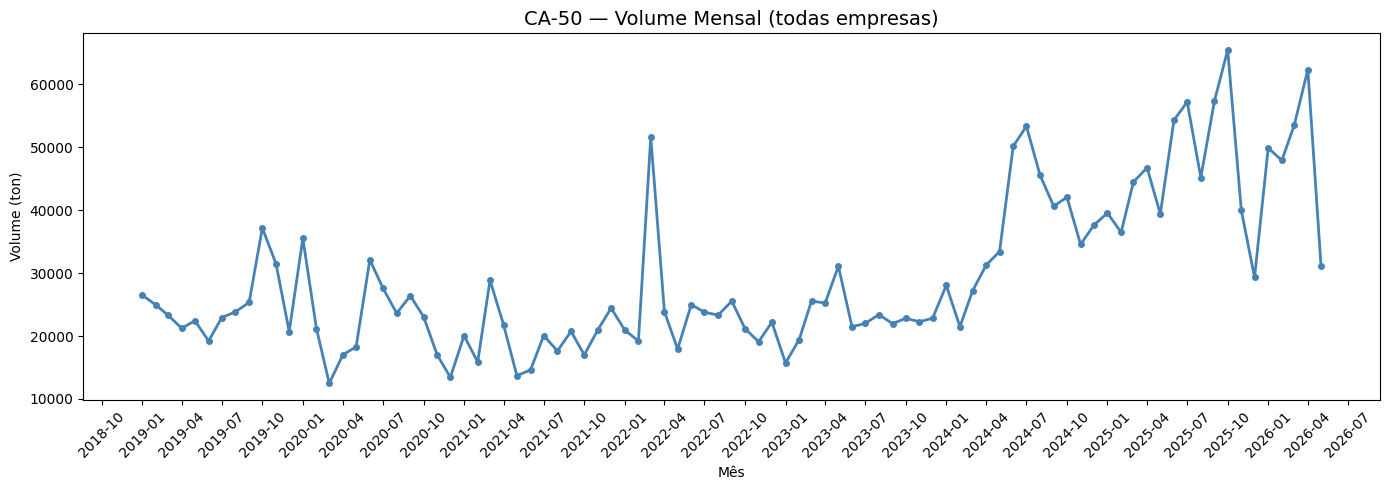

Gráfico salvo em outputs/


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Salva base processada
df_mensal.to_csv(r'C:\Users\samuel.bandeira\lstm-forecast-demanda\data\processed\vendas_mensal.csv', index=False)
print("Base salva em data/processed/")

# Agrega CA-50 consolidado (todas empresas e regiões)
ca50 = df_mensal[df_mensal['linha'] == 'CA-50'].groupby('mes').agg(vol_ton=('vol_ton', 'sum')).reset_index()
ca50['mes_dt'] = ca50['mes'].dt.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ca50['mes_dt'], ca50['vol_ton'], marker='o', linewidth=2, markersize=4, color='steelblue')
ax.set_title('CA-50 — Volume Mensal (todas empresas)', fontsize=14)
ax.set_xlabel('Mês')
ax.set_ylabel('Volume (ton)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\samuel.bandeira\lstm-forecast-demanda\outputs\ca50_serie_temporal.png', dpi=150)
plt.show()
print("Gráfico salvo em outputs/")

In [7]:
# Verifica pontos de 2018
print("=== PONTOS ANTES DE 2019 ===")
print(df_mensal[df_mensal['mes'] < '2019-01'][['mes', 'empresa', 'linha', 'vol_ton']].head(20))

# Verifica os dois picos extremos do CA-50
print("\n=== MAIORES VOLUMES CA-50 ===")
ca50_top = ca50.nlargest(5, 'vol_ton')
print(ca50_top[['mes', 'vol_ton']])

# Verifica menor volume CA-50
print("\n=== MENORES VOLUMES CA-50 ===")
ca50_bot = ca50.nsmallest(5, 'vol_ton')
print(ca50_bot[['mes', 'vol_ton']])

=== PONTOS ANTES DE 2019 ===
Empty DataFrame
Columns: [mes, empresa, linha, vol_ton]
Index: []

=== MAIORES VOLUMES CA-50 ===
        mes      vol_ton
81  2025-10  65451.44000
87  2026-04  62344.48582
80  2025-09  57385.77000
78  2025-07  57197.74000
77  2025-06  54299.14000

=== MENORES VOLUMES CA-50 ===
        mes   vol_ton
14  2020-03  12485.87
23  2020-12  13437.53
28  2021-05  13701.74
29  2021-06  14618.31
48  2023-01  15728.87


=== REGISTROS POR REGIME ===
                    count        mean   median
expansao_laminador                            
0                   31706  139.019775  25.8300
1                   11700  198.141229  30.2053


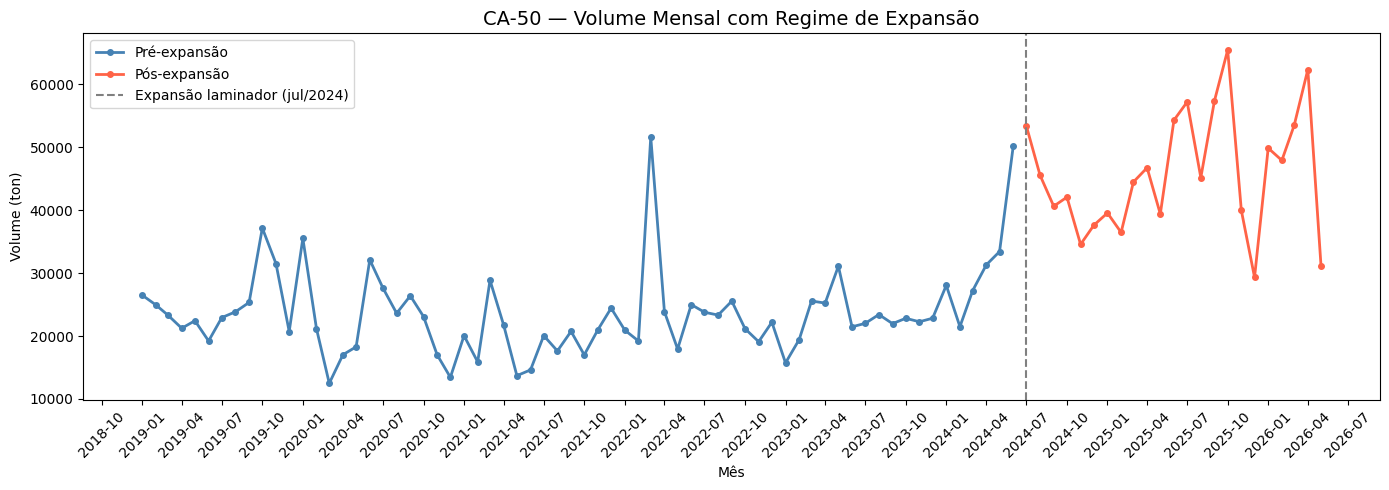

In [8]:
# Adiciona feature de expansão
df_mensal['expansao_laminador'] = (df_mensal['mes'] >= '2024-07').astype(int)

# Verifica distribuição
print("=== REGISTROS POR REGIME ===")
print(df_mensal.groupby('expansao_laminador')['vol_ton'].agg(['count', 'mean', 'median']))

# Plota CA-50 com os dois regimes coloridos
ca50 = df_mensal[df_mensal['linha'] == 'CA-50'].groupby(['mes', 'expansao_laminador']).agg(vol_ton=('vol_ton', 'sum')).reset_index()
ca50['mes_dt'] = ca50['mes'].dt.to_timestamp()

pre = ca50[ca50['expansao_laminador'] == 0]
pos = ca50[ca50['expansao_laminador'] == 1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pre['mes_dt'], pre['vol_ton'], marker='o', linewidth=2, markersize=4, color='steelblue', label='Pré-expansão')
ax.plot(pos['mes_dt'], pos['vol_ton'], marker='o', linewidth=2, markersize=4, color='tomato', label='Pós-expansão')
ax.axvline(pd.Timestamp('2024-07-01'), color='gray', linestyle='--', linewidth=1.5, label='Expansão laminador (jul/2024)')
ax.set_title('CA-50 — Volume Mensal com Regime de Expansão', fontsize=14)
ax.set_xlabel('Mês')
ax.set_ylabel('Volume (ton)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\samuel.bandeira\lstm-forecast-demanda\outputs\ca50_regimes.png', dpi=150)
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Carrega base processada
df = pd.read_csv(r'C:\Users\samuel.bandeira\lstm-forecast-demanda\data\processed\vendas_mensal.csv')

print(f"Shape: {df.shape}")
print(df.dtypes)
print(df.head(3))

Shape: (43406, 7)
mes         object
empresa     object
regiao      object
uf          object
linha       object
vol_ton    float64
val_mm     float64
dtype: object
       mes empresa        regiao  uf           linha  vol_ton  val_mm
0  2019-01     ACC  Centro Oeste  DF      Inox Chapa     1.47   18.37
1  2019-01     ACC  Centro Oeste  GO  Barra Laminada     0.60    2.39
2  2019-01     ACC  Centro Oeste  GO     Inox Bobina     5.12   53.45
